- У нас есть банковский счет. Его можно открыть в 3 валютах: бел, дол, евро
- есть банковский аккаунт: все наши счета с валютами там[список из объектов]
- можем перегонять из евро в доллары и т.п. и в другой счет другого
- все владельцы аккаунтов заранее прописаны
- нарисовать схему этих классов с помощью графических инструментов, какой класс, какие типы какие атрибуты и отрисовать их взаимодействие (емл диаграмма?)
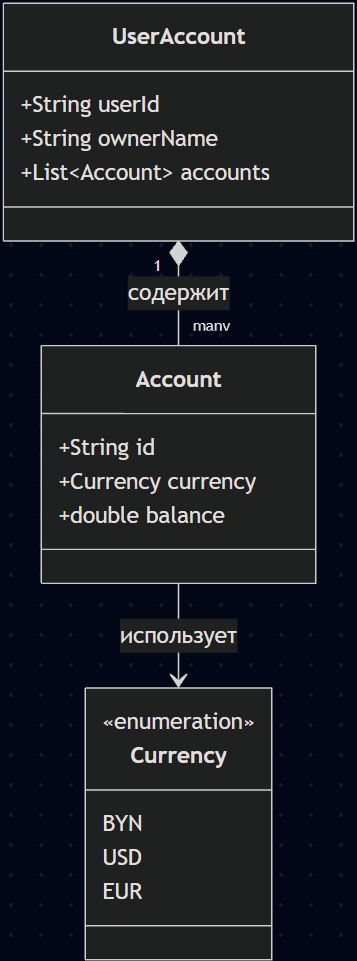

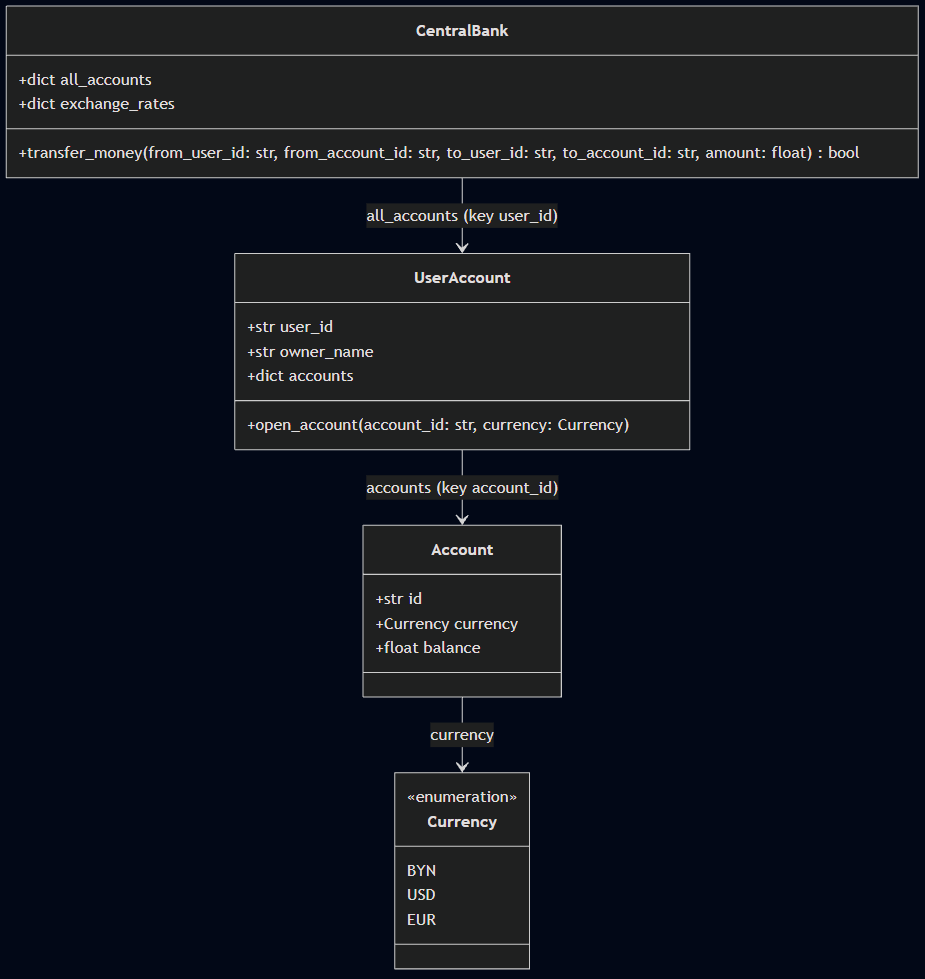
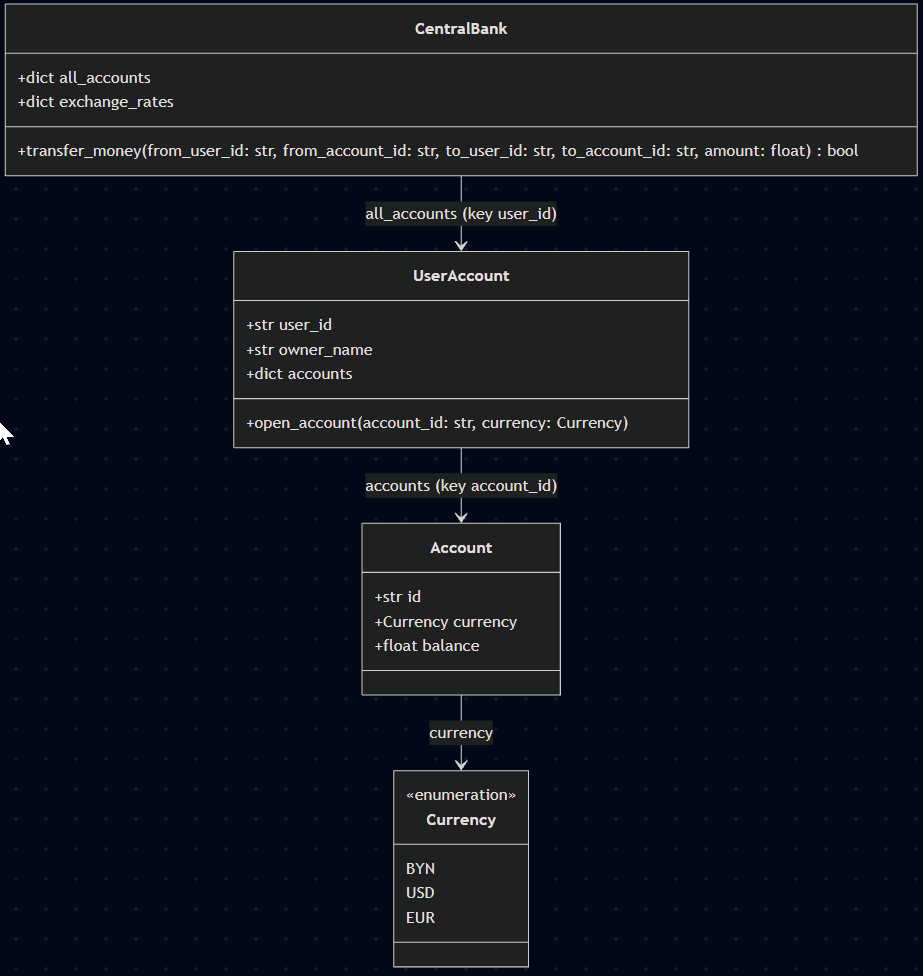

In [ ]:
from enum import StrEnum

# класс для переводов денег между юзерами
class CentralBank:
    def __init__(self):
        # пустая библиотека всех аккаунтов для дальнейшего добавления
        self.all_accounts = {}
        # курс валют
        self.exchange_rates = {
            'USD_BYN': 2.79,
            'USD_EUR': 0.86,
            'BYN_USD': 0.36,
            'BYN_EUR': 0.31,
            'EUR_USD': 1.16,
            'EUR_BYN': 3.24
        }

    def transfer_money(self, from_user_id, from_account_id, to_user_id, to_account_id, amount):
        # Проверяем наличие пользователя, а затем наличие счетов у них
        if (to_user_id in self.all_accounts) and (from_user_id in self.all_accounts):
            if (to_account_id in self.all_accounts[to_user_id].accounts) and (
                    from_account_id in self.all_accounts[from_user_id].accounts):

                # присваиваем один из аккаунтов отправителя по айди юзера из списка всех аккаунтов в банке по айди аккаунта
                sender_account = self.all_accounts[from_user_id].accounts[from_account_id]
                # присваиваем один из аккаунтов получателя по айди юзера из списка всех аккаунтов в банке по айди аккаунта
                receiver_account = self.all_accounts[to_user_id].accounts[to_account_id]

                # проверяем достаточно ли денег на счету отправителя который мы получили ранее
                if sender_account.balance >= amount:
                    sender_account.balance -= amount
                    if sender_account.currency == receiver_account.currency:
                        receiver_account.balance += amount
                    else:
                        exchange_sum = sender_account.currency + '_' + receiver_account.currency
                        rate = self.exchange_rates.get(exchange_sum)
                        receiver_account.balance += amount * rate
                        print(f"Перевод {amount} {sender_account.currency} успешно выполнен!")
                        # досрочно завершаем работу функции и возвращаем успешность операции
                        return True
                else:
                    print("Недостаточно средств на счете отправителя.")
            else:
                print("Указанные счета не найдены")
        else:
            print("Пользователь не зарегистрирован в банке")
        # завершаем работу функции и даём понять что операция не выполнена(на будущее это можно будет использовать вместо обычно получаемого None в случае отсутствия return)
        return False

# класс для передачи элемента, например: Currency.USD
class Currency(StrEnum):
    BYN = 'BYN'
    USD = 'USD'
    EUR = 'EUR'

# счёт юзера с валютой, айди счета и балансом
class Account:
    def __init__(self, id, currency, balance = 0.0):
        self.id = id
        self.currency = currency
        self.balance = balance

# аккаунт со счетами, айди и именем юзера
class UserAccount:
    def __init__(self, user_id, owner_name):
        self.user_id = user_id
        self.owner_name = owner_name
        self.accounts = {}

    def open_account(self, account_id, currency):
        self.accounts.update({account_id: Account(account_id, currency, 0.0)})

# создаем экземпляр банка для переводов
main_bank = CentralBank()
# создаем аккаунты юзеров и присваиваем айди аккаунта и имя юзера
user1 = UserAccount('user_1', "Ivan")
user2 = UserAccount('user_2', "Masha")
# добавляем аккаунты юзеров в банк для возможности дальнейших переводов
main_bank.all_accounts['user_1'] = user1
main_bank.all_accounts['user_2'] = user2
# открываем счета у юзеров в нужной нам валюте и присваиваем айди
user1.open_account('acc_1', Currency.USD)
user2.open_account('acc_2', Currency.EUR)
# закидываем денег на счёт юзерам
user1.accounts['acc_1'].balance += 100
user2.accounts['acc_2'].balance += 100
# переводим денег
main_bank.transfer_money('user_1', 'acc_1', 'user_2', 'acc_2', 100)
# смотрим скока денег после транзакции
print(main_bank.all_accounts['user_1'].accounts['acc_1'].balance)
print(main_bank.all_accounts['user_2'].accounts['acc_2'].balance)